# Mach-Zehnder Modulator (MZM) -- $V_\pi$-Defined Push-Pull Design, Meep Baseline, and $\Delta n$ Sweep

This notebook builds and validates a **Mach-Zehnder Modulator**: the active
counterpart to `07_mzi.ipynb`'s passive Mach-Zehnder Interferometer. Both
devices share the same two `coupler.py` 50:50 splitter/combiner stages; where
the MZI creates interference via a fixed geometric path-length difference
$\Delta L$, this device keeps both arms the **same physical length** and
creates a *controllable* phase difference via a push-pull electro-optic index
perturbation $\Delta n(x)$ on both arms.

**The operating point is *defined*, not searched for.** Unlike the coupling
length (`06_directional_coupler.ipynb`, found by sweep + interpolation) or the
MZI's arm-length difference (`07_mzi.ipynb`, found by sweep + selection), this
notebook is handed a target directly: push-pull
$n_\mathrm{upper}=n_\mathrm{core}+\Delta n/2$,
$n_\mathrm{lower}=n_\mathrm{core}-\Delta n/2$, with
$\Delta n_{V_\pi}=0.002$ defined as the point at which the device should
deliver a full $\pi$ phase swing. Section 2 derives the arm length this
implies; Section 7 Meep-validates how close the derived length actually lands
to a true $\pi$ swing, and reports the real confinement factor honestly
rather than forcing agreement with the prior used to size it.

Like every earlier notebook, this one is an educational/validation record,
not just a script -- work through it step by step, and stop at the marked
checkpoints to actually look at the plots before continuing. **Do not use
"Run All."**

**Runtime note**: this device's arm alone is roughly 5x longer than
`07_mzi.ipynb`'s, so its simulation cell is the longest in this toolkit.
`resolution` is left at this toolkit's standard 25 px/um rather than raised
further; Sections 5, 10, and 12 are all genuinely slow (expect hours, not
minutes, especially Section 12's path-length-bias check, whose delay-arm
bump also widens the cell).

## 1. Physical objective

A Mach-Zehnder Modulator converts an electrical drive signal into optical
intensity/phase modulation by shifting one or both interferometer arms'
effective index. In a real device, a voltage reverse-biases a PN junction in
the waveguide core, depleting free carriers and shifting $n_\mathrm{eff}$ via
the plasma-dispersion effect -- typically only $\Delta n\sim10^{-4}$, which is
why real phase-shifter lengths run hundreds of microns to millimeters.

**This notebook does not model that electrical mechanism.** Converting a
drive voltage to a specific $\Delta n$ needs a real carrier-transport
calculation, out of scope here -- the same limitation `coupler.py`/`racetrack.py`'s
own electro-optic-adjacent components share. Everything below works directly
in terms of $\Delta n$, with $\Delta n_{V_\pi}$ standing in for "however large
a $\Delta n$ a real drive voltage would produce."

**Push-pull, not single-arm.** Driving both arms with opposite-sign $\Delta n$
doubles the achievable differential phase for a given $|\Delta n|$ compared to
perturbing one arm alone, directly shortening the phase-shifter length needed
to reach $\pi$.

In [1]:
import inspect
import json

import numpy as np
import matplotlib.pyplot as plt
import gdsfactory as gf

from pic_toolkit.meep_sim import mzm
from pic_toolkit import viz, design_points, sweep as sweep_mod, style

style.apply_style()  # shared color palette + plot style for every notebook in this toolkit
%matplotlib inline

# ============================================================
# USER PARAMETERS
# ============================================================
params = dict(mzm.DEFAULT_PARAMS)
params


### Cross-check against the reused directional-coupler design point

The splitter/combiner stages are `coupler.py`'s own validated 50:50 design,
reused verbatim (not re-swept here) -- same discipline `07_mzi.ipynb` already
follows for the same reason.

In [2]:
coupler_design_point = design_points.load_design_point("../data/design_points/coupler.yaml")
assert params["coupling_length_um"] == coupler_design_point["parameters"]["coupling_length_um"], (
    "mzm.DEFAULT_PARAMS['coupling_length_um'] no longer matches the coupler's saved design point -- "
    "if 06_directional_coupler.ipynb was re-run and selected a different value, update mzm.py's "
    "DEFAULT_PARAMS to match it."
)
print("coupling_length_um matches data/design_points/coupler.yaml:", params["coupling_length_um"])


coupling_length_um matches data/design_points/coupler.yaml: 13.848128928800111


### $V_\pi$-derived arm length

$$\pi = \Gamma_\mathrm{core}\cdot\frac{2\pi}{\lambda_0}\cdot\Delta n_{V_\pi}\cdot L_\mathrm{plateau}
\quad\Longrightarrow\quad
L_\mathrm{plateau} = \frac{\lambda_0}{2\,\Gamma_\mathrm{core}\,\Delta n_{V_\pi}}$$

using `gamma_core_prior` (see `mzm.DEFAULT_PARAMS`'s comment for where this
prior comes from) as the best available estimate for *sizing* the arm --
Section 7 measures the real confinement factor from an actual Meep run at
this design point and reports it without forcing agreement.

In [3]:
print(inspect.getsource(mzm.plateau_length_um))
print(inspect.getsource(mzm.arm_length_um))

PLATEAU_LENGTH_UM = mzm.plateau_length_um(params)
ARM_LENGTH_UM = mzm.arm_length_um(params)
print(f"\nPLATEAU_LENGTH_UM = {PLATEAU_LENGTH_UM:.1f} um")
print(f"ARM_LENGTH_UM     = {ARM_LENGTH_UM:.1f} um  (plateau + 2*margin_sigma*sigma_um)")


def plateau_length_um(params: dict) -> float:
    """Idealized-then-confinement-corrected plateau length for a pi push-pull
    swing at Delta_n = delta_n_vpi:
        pi = Gamma_core * (2*pi/wl0) * Delta_n * L  =>  L = wl0 / (2*Gamma_core*Delta_n)
    Uses gamma_core_prior (see its DEFAULT_PARAMS comment) as the best
    available estimate for sizing -- not re-derived from a measurement in
    this module itself.
    """
    return params["wl0_um"] / (2.0 * params["gamma_core_prior"] * params["delta_n_vpi"])

def arm_length_um(params: dict) -> float:
    """Total arm length actually built: the phase-active plateau plus an
    inactive erf-ramp margin at each end (see margin_sigma/sigma_um)."""
    return plateau_length_um(params) + 2 * params["margin_sigma"] * params["sigma_um"]


PLATEAU_LENGTH_UM = 330.9 um
ARM_LENGTH_UM     = 354.9 um  (plateau + 2*margin_sigma*sigma_um)


## 2. Build geometry

Both arms extend directly from the coupler stages' own `out_top`/`out_bot`
ports at `wide_sep_um` separation. The push-pull $\Delta n$ overlay
(`mzm.build_index_perturbation`, an erf ramp) is confined to a plateau region
that has already decayed to ~0 well before either coupler stage -- any
leakage there would detune the coupler's carefully-measured 50:50 split.

In [4]:
print(inspect.getsource(mzm.build_index_perturbation))
print(inspect.getsource(mzm.build_geometry))


def build_index_perturbation(x, x1, x2, delta_n_max, sigma):
    """Smooth (erf) Delta_n(x) profile: ~0 outside [x1, x2], ~delta_n_max
    inside, with transition width `sigma` at each edge -- avoids the
    reflection a hard step discontinuity in Delta_n would cause."""
    return 0.5 * delta_n_max * (erf((x - x1) / sigma) - erf((x - x2) / sigma))

def build_geometry(params: dict, delta_n_lower: float = 0.0, delta_n_upper: float = 0.0) -> list:
    """Two coupler stages (splitter, combiner), each coupler.build_geometry's
    own validated 50:50 shape translated into place, joined by two arms of
    IDENTICAL physical length extending directly from the coupler ports' own
    wide_sep_um separation: the top arm carries delta_n_upper, the bottom arm
    carries delta_n_lower, each as an erf-ramped overlay (build_index_
    perturbation) confined to the plateau region (px1, px2) -- ~0 by
    construction at either coupler stage. When delta_L_um > 0, the bottom arm
    additionally carries

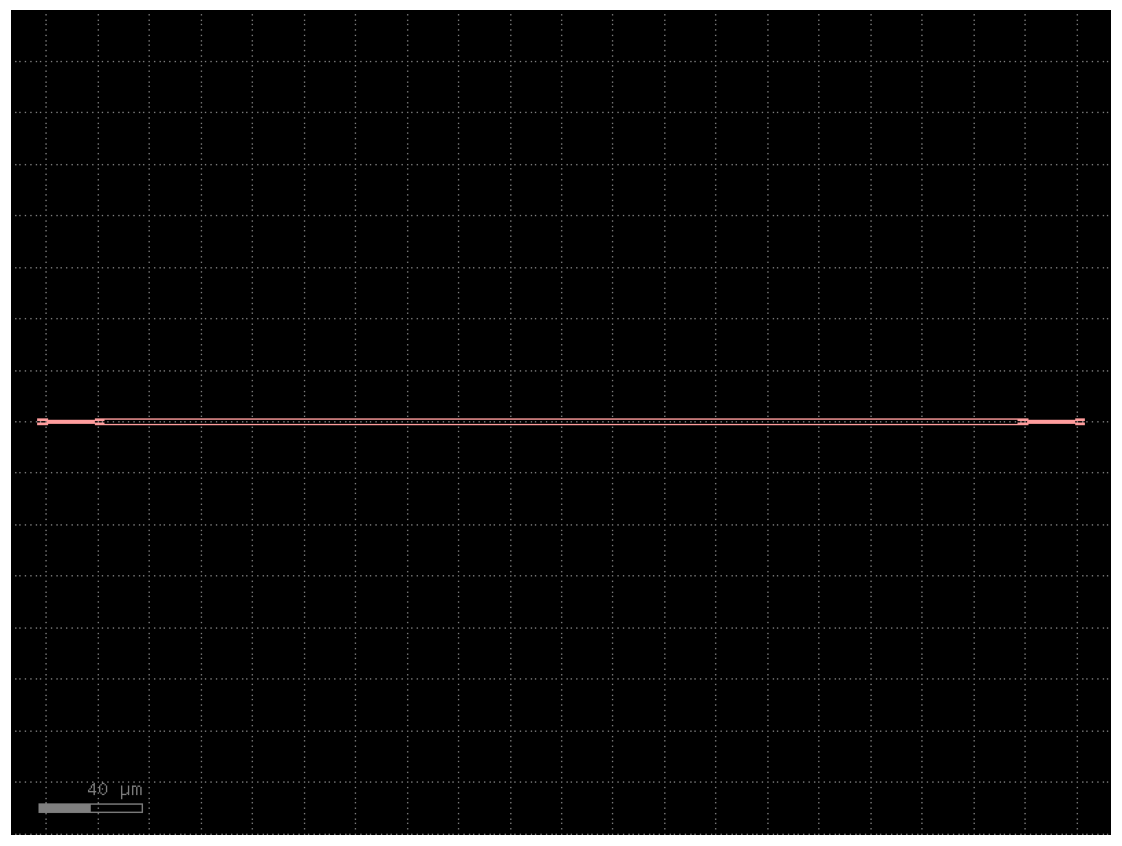

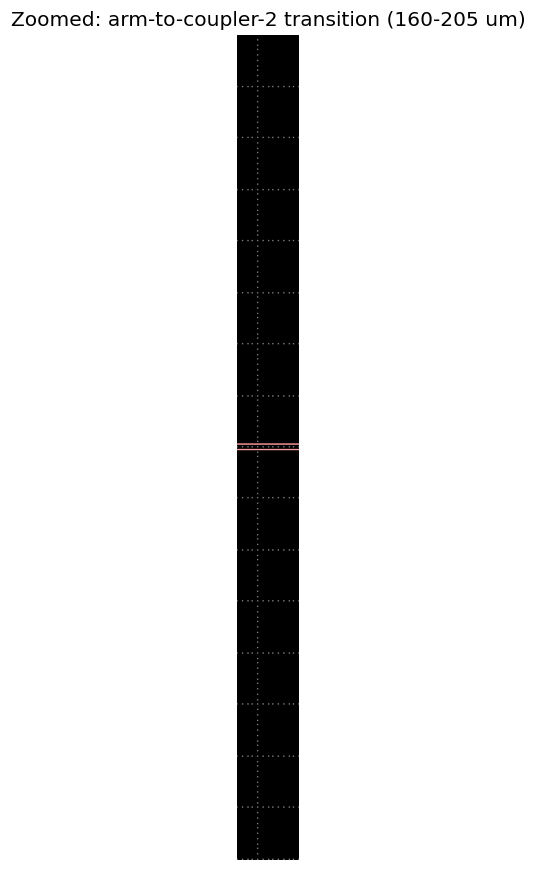

In [5]:
gf_component = mzm.build_gf_component(params)
fig = gf_component.plot()
plt.show()

## 3. Permittivity map

Native (`mp.Medium`-function) vs. gdsfactory-derived geometry, same
native-vs-gds diff discipline every earlier notebook follows (CLAUDE.md
Sec. 4) -- though only the native path can show the real $\Delta n(x)$
overlay at all, since gdsfactory has no notion of a spatially-varying index.
Shown here at the $V_\pi$ push-pull-ON operating point.

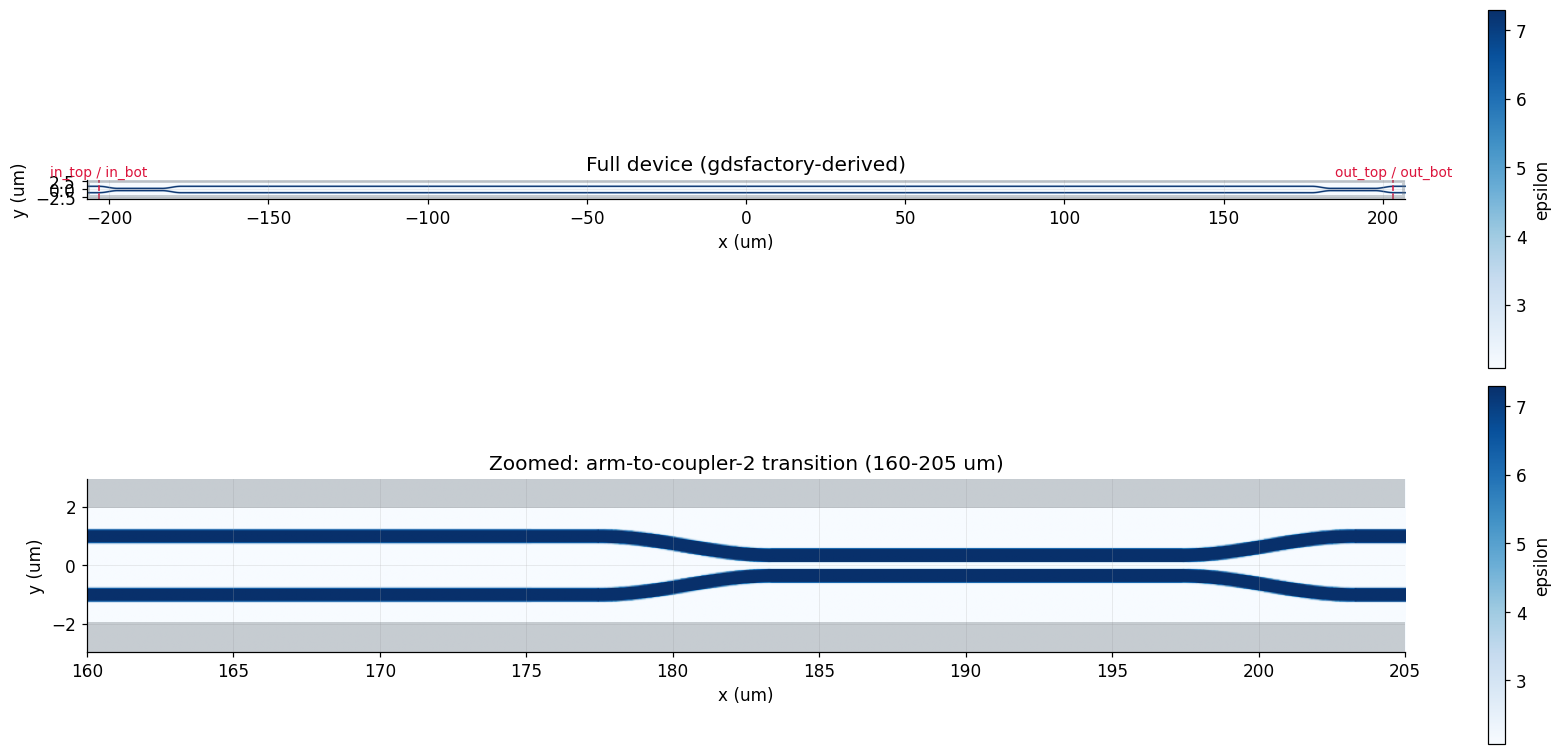

In [6]:
DN_LOWER_ON = -params["delta_n_vpi"] / 2
DN_UPPER_ON = params["delta_n_vpi"] / 2

perm_map = mzm.get_permittivity_map(params, DN_LOWER_ON, DN_UPPER_ON, use_native_geometry=False)
ports = mzm._ports(params)
port_marks = [
    (ports["in_top"].x, 0, "in_top / in_bot", "v"),
    (ports["out_top"].x, 0, "out_top / out_bot", "v"),
]

fig, (ax_full, ax_zoom) = plt.subplots(2, 1, figsize=(16, 7))
viz.plot_permittivity(perm_map.eps, perm_map.extent_um, ax=ax_full, pml_um=params["dpml_um"], ports=port_marks)
ax_full.set_title("Full device (gdsfactory-derived)")
viz.plot_permittivity(perm_map.eps, perm_map.extent_um, ax=ax_zoom, pml_um=params["dpml_um"])
ax_zoom.set_xlim(160, 205)
ax_zoom.set_title("Zoomed: arm-to-coupler-2 transition (160-205 um)")
fig.tight_layout()
plt.show()


native vs. gdsfactory permittivity diff: max=2.334  mean=0.03105  fraction of pixels differing by >0.01 = 4.9847%


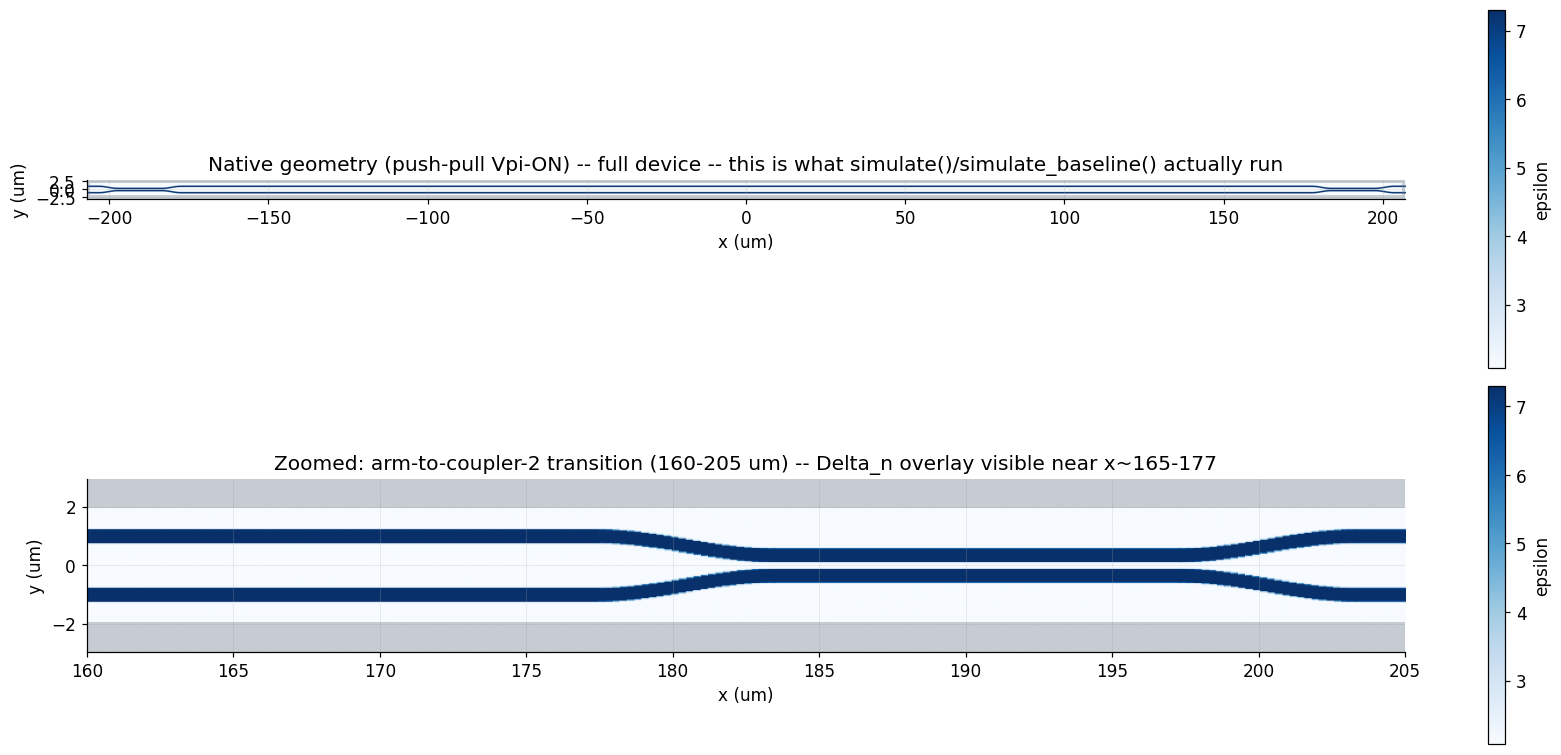

In [7]:
perm_map_native = mzm.get_permittivity_map(params, DN_LOWER_ON, DN_UPPER_ON, use_native_geometry=True)
diff = np.abs(perm_map_native.eps - perm_map.eps)
print(f"native vs. gdsfactory permittivity diff: max={diff.max():.3f}  mean={diff.mean():.5f}  "
      f"fraction of pixels differing by >0.01 = {(diff > 0.01).mean():.4%}")

fig, (ax_full, ax_zoom) = plt.subplots(2, 1, figsize=(16, 7))
viz.plot_permittivity(perm_map_native.eps, perm_map_native.extent_um, ax=ax_full, pml_um=params["dpml_um"])
ax_full.set_title("Native geometry (push-pull Vpi-ON) -- full device -- this is what simulate()/simulate_baseline() actually run")
viz.plot_permittivity(perm_map_native.eps, perm_map_native.extent_um, ax=ax_zoom, pml_um=params["dpml_um"])
ax_zoom.set_xlim(160, 205)
ax_zoom.set_title("Zoomed: arm-to-coupler-2 transition (160-205 um) -- Delta_n overlay visible near x~165-177")
fig.tight_layout()
plt.show()


> **STOP -- INSPECT THE PERMITTIVITY MAP BEFORE RUNNING FDTD.** Confirm
> both coupler stages look like `06_directional_coupler.ipynb`'s own
> validated geometry, and that the arm looks like a single straight
> waveguide (the $\Delta n$ overlay is a real-valued index perturbation, not
> a visible structural change in permittivity at this color scale).

## 4. Baseline FDTD simulation

Full 4-port characterization at the $V_\pi$ push-pull-ON operating point:
excite `in_top` **and** `in_bot` independently, enabling a genuine
Lorentz-reciprocity check ($S_{21}$ vs $S_{12}$) -- the same discipline
`07_mzi.ipynb`'s own baseline follows. This is the one operating point this
notebook validates at full (strict-tolerance) rigor.

> **STOP -- this is the slowest single cell in the notebook (two full FDTD
> runs on this device's long domain).**

In [8]:
print(inspect.getsource(mzm.simulate_baseline))


def simulate_baseline(params: dict | None = None, delta_n_lower: float | None = None,
                       delta_n_upper: float | None = None) -> MZMResult:
    """Full 4-port characterization at the canonical push-pull-ON operating
    point (default: delta_n_lower=-delta_n_vpi/2, delta_n_upper=+delta_n_vpi/2,
    i.e. the Vpi design point itself): excite in_top (port 1) AND in_bot
    (port 2) independently, enabling a genuine Lorentz-reciprocity check
    (S21 vs S12) the same way mzi.py's own baseline does. This is the one
    operating point this module validates at full (strict-tolerance) rigor;
    the Delta_n sweep and delta_L_um check (Sections 10/12) use the cheaper
    single-excitation `simulate` instead.
    """
    params = {**DEFAULT_PARAMS, **(params or {})}
    if delta_n_lower is None:
        delta_n_lower = -params["delta_n_vpi"] / 2
    if delta_n_upper is None:
        delta_n_upper = params["delta_n_vpi"] / 2

    freqs, inc1, refl1, cross1, top1, bot1, field_s

In [9]:
result = mzm.simulate_baseline(params)
print("done. wavelengths (um):", result.wavelengths_um.min(), "-", result.wavelengths_um.max())


done. wavelengths (um): 1.301721854304636 - 1.4019971469329529


## 5. Electromagnetic field visualization -- polarization convention

`eig_parity=mp.TE` is forced at every source/monitor (CLAUDE.md Sec. 5); the
DFT field capture records whichever of $E_z$/$H_z$ actually dominates rather
than assuming either, same convention `coupler.py` already established.

dominant field component: Hz


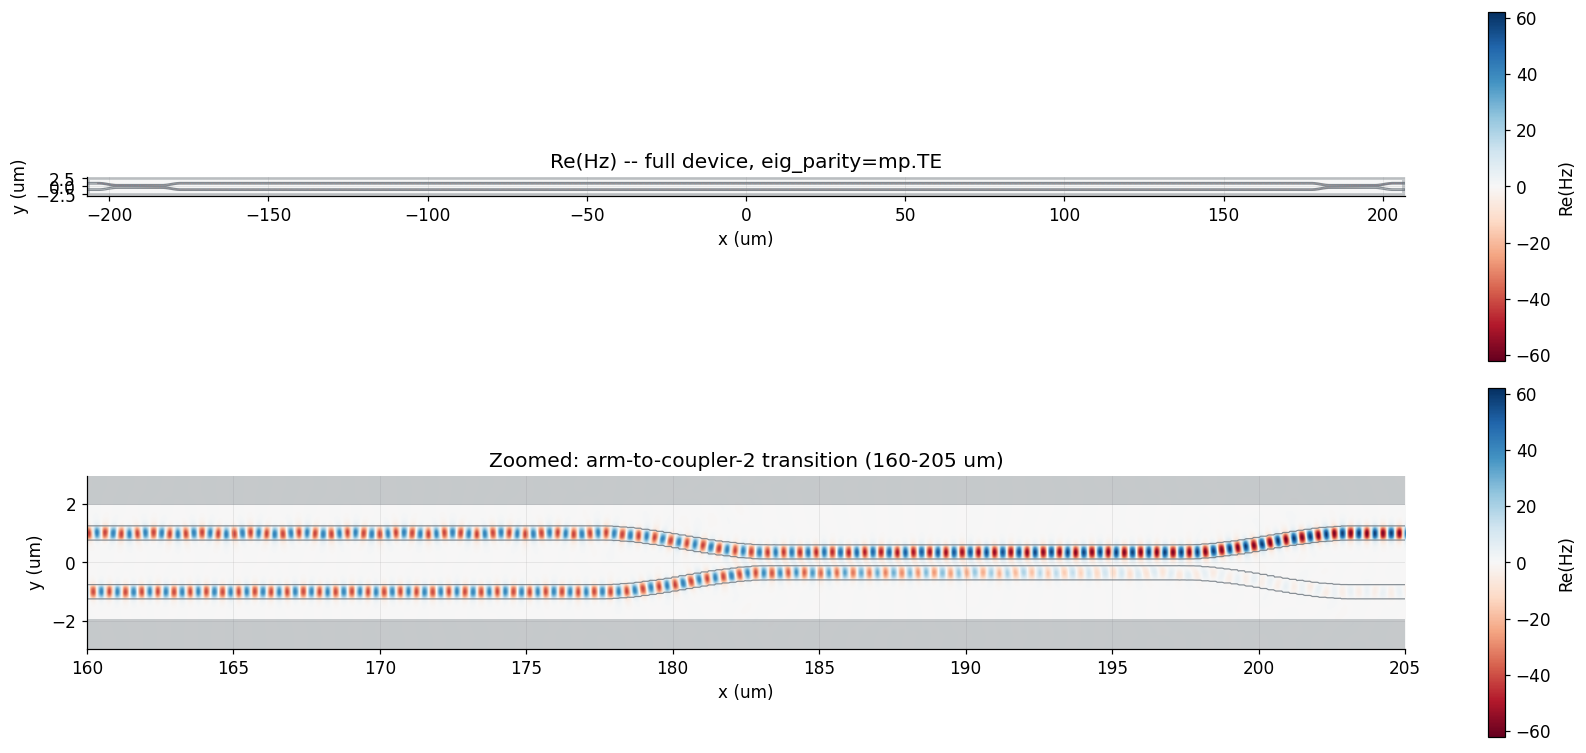

In [8]:
# Re-capture the field via a single-excitation run at the same Vpi push-pull-ON point
# simulate_baseline() already validated above -- cheaper than re-running the full
# dual-excitation baseline just to get its (never separately saved) raw field array again.
field_result = mzm.simulate(params, delta_n_lower=DN_LOWER_ON, delta_n_upper=DN_UPPER_ON, capture_dft=True)
snap = field_result.field_snapshot

fig, (ax_full, ax_zoom) = plt.subplots(2, 1, figsize=(16, 7))
viz.plot_field(snap.field, snap.eps, snap.extent_um, component=snap.component, ax=ax_full, pml_um=params["dpml_um"])
ax_full.set_title(f"Re({snap.component}) -- full device, eig_parity=mp.TE")
viz.plot_field(snap.field, snap.eps, snap.extent_um, component=snap.component, ax=ax_zoom, pml_um=params["dpml_um"])
ax_zoom.set_xlim(160, 205)
ax_zoom.set_title("Zoomed: arm-to-coupler-2 transition (160-205 um)")
fig.tight_layout()
plt.show()
print(f"dominant field component: {snap.component}")


> **STOP -- INSPECT THE ELECTROMAGNETIC FIELD BEFORE CONTINUING.** Confirm
> the input mode splits at the first coupler, propagates down both arms, and
> recombines at the second coupler -- and that `Hz` (not `Ez`) dominates,
> confirming genuine TE propagation (CLAUDE.md Sec. 5).

## 6. Transmission and phase spectra

Port convention (matching `07_mzi.ipynb`): port 1 = `in_top`, port 2 =
`in_bot`, port 3 = `out_top`, port 4 = `out_bot`. $S_{31}$/$S_{41}$ are the
through ("bar")/cross response to a port-1 excitation.

Shown below for **both** the $V_\pi$-ON push-pull state (this notebook's baseline, Section 4) and the unperturbed OFF state ($\Delta n=0$, reused from Section 9's sweep rather than re-simulated) side by side, so the modulation itself is visible directly in the spectra rather than only as a single-wavelength number.

ON  @ wl0=1.35 um: |S31|^2=0.9833  |S41|^2=0.0042  |S11|^2=0.0002
OFF @ wl0=1.35 um: |S31|^2=0.0000  |S41|^2=0.9882  |S11|^2=0.0001


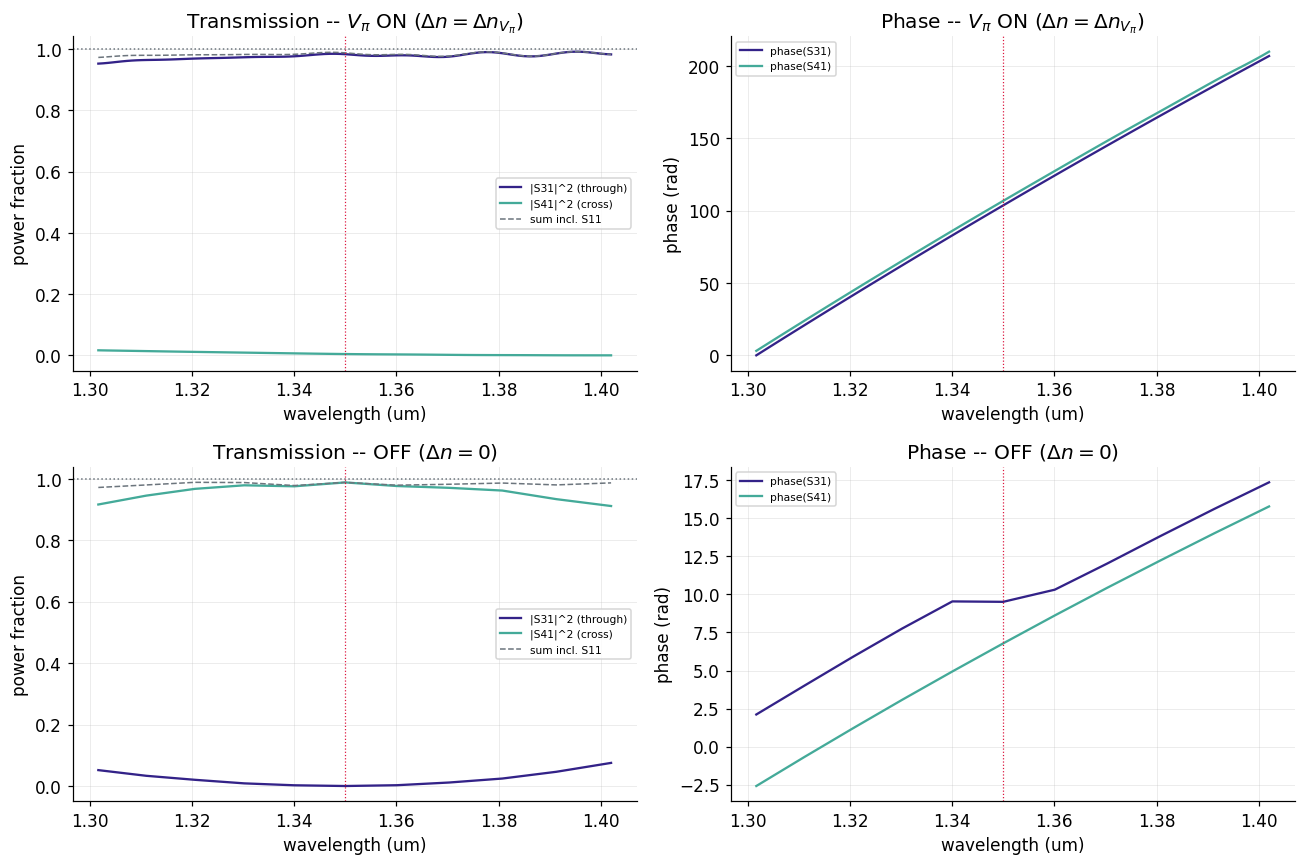

In [11]:
baseline_artifact = mzm.load_artifact("../data/sparams/mzm/baseline/mzm_baseline")
off_artifact = mzm.load_artifact("../data/sparams/mzm/sweep/mzm_dn0p0000")
# NOTE: off_artifact comes from Section 9's delta_n sweep (n_freq=11, coarser than the
# baseline's own n_freq=101) -- reused rather than re-simulated at full resolution, since a
# second full dual-excitation OFF-state baseline would cost as much as the ON-state one did.

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
(ax_mag_on, ax_phase_on), (ax_mag_off, ax_phase_off) = axes

for ax_mag, ax_phase, art, label in [
    (ax_mag_on, ax_phase_on, baseline_artifact, r"$V_\pi$ ON ($\Delta n=\Delta n_{V_\pi}$)"),
    (ax_mag_off, ax_phase_off, off_artifact, r"OFF ($\Delta n=0$)"),
]:
    wl = art.wavelengths_um
    order = np.argsort(wl)
    wl_s, S31_s, S41_s, S11_s = wl[order], art.S31[order], art.S41[order], art.S11[order]

    ax_mag.plot(wl_s, np.abs(S31_s) ** 2, color=style.COLOR_CYCLE[0], label="|S31|^2 (through)")
    ax_mag.plot(wl_s, np.abs(S41_s) ** 2, color=style.COLOR_CYCLE[2], label="|S41|^2 (cross)")
    ax_mag.plot(wl_s, np.abs(S31_s) ** 2 + np.abs(S41_s) ** 2 + np.abs(S11_s) ** 2,
                "--", color=style.COLOR_REFERENCE, lw=1, label="sum incl. S11")
    ax_mag.axhline(1.0, color=style.COLOR_REFERENCE, ls=":", lw=1)
    ax_mag.axvline(params["wl0_um"], color=style.COLOR_ANNOTATION, lw=0.8, ls=":")
    ax_mag.set_xlabel("wavelength (um)"); ax_mag.set_ylabel("power fraction")
    ax_mag.set_title(f"Transmission -- {label}"); ax_mag.legend(fontsize=7)

    ax_phase.plot(wl_s, np.unwrap(np.angle(S31_s)), color=style.COLOR_CYCLE[0], label="phase(S31)")
    ax_phase.plot(wl_s, np.unwrap(np.angle(S41_s)), color=style.COLOR_CYCLE[2], label="phase(S41)")
    ax_phase.axvline(params["wl0_um"], color=style.COLOR_ANNOTATION, lw=0.8, ls=":")
    ax_phase.set_xlabel("wavelength (um)"); ax_phase.set_ylabel("phase (rad)")
    ax_phase.set_title(f"Phase -- {label}"); ax_phase.legend(fontsize=7)

fig.tight_layout()
plt.show()

i0_on = np.argmin(np.abs(baseline_artifact.wavelengths_um - params["wl0_um"]))
i0_off = np.argmin(np.abs(off_artifact.wavelengths_um - params["wl0_um"]))
print(f"ON  @ wl0={params['wl0_um']} um: |S31|^2={np.abs(baseline_artifact.S31[i0_on])**2:.4f}  "
      f"|S41|^2={np.abs(baseline_artifact.S41[i0_on])**2:.4f}  |S11|^2={np.abs(baseline_artifact.S11[i0_on])**2:.4f}")
print(f"OFF @ wl0={params['wl0_um']} um: |S31|^2={np.abs(off_artifact.S31[i0_off])**2:.4f}  "
      f"|S41|^2={np.abs(off_artifact.S41[i0_off])**2:.4f}  |S11|^2={np.abs(off_artifact.S11[i0_off])**2:.4f}")


## 7. Physics sanity checks

Tolerances start from `07_mzi.ipynb`'s own already-measured values (the
closest precedent: another long-domain, two-coupler-stage device) since this
is a new component with no prior measurement of its own -- CLAUDE.md's
"measure first" discipline means these may need loosening once the actual
deviation below is known; do not tighten them below what is actually
observed.

In [12]:
ENERGY_TOL = 0.08          # starting point: 07_mzi.ipynb's own measured worst case was ~0.074
RECIPROCITY_TOL = 0.05
PASSIVITY_TOL = 0.01
MAX_EXPECTED_LOSS = 0.08

validation = mzm.run_all_checks(result, energy_tol=ENERGY_TOL, reciprocity_tol=RECIPROCITY_TOL,
                                 passivity_tol=PASSIVITY_TOL, max_expected_loss=MAX_EXPECTED_LOSS)
print(json.dumps(validation, indent=2))
assert validation["passed"], "Baseline failed sanity checks -- do not save or use this result."


{
  "energy_conservation": {
    "max_deviation_port1": 0.0,
    "max_deviation_port2": 0.0,
    "max_deviation": 0.0,
    "max_expected_loss": 0.08,
    "tolerance": 0.08,
    "passed": true
  },
  "reciprocity": {
    "max_diff": 0.00013225902469494563,
    "tolerance": 0.05,
    "passed": true
  },
  "passivity": {
    "max_power_fraction": 0.9915672329171963,
    "tolerance": 0.01,
    "passed": true
  },
  "passed": true
}


## 8. Save baseline artifact

In [13]:
artifact_stem = "../data/sparams/mzm/baseline/mzm_baseline"
metadata = {
    "component": "mzm",
    "geometry_params": {k: v for k, v in params.items() if k.endswith("_um")},
    "material_params": {k: params[k] for k in ["core_index", "clad_index"]},
    "polarization": "TE (forced via eig_parity=mp.TE)",
    "meep_resolution": params["resolution"],
    "delta_n_vpi": params["delta_n_vpi"],
    "arm_length_um": ARM_LENGTH_UM, "plateau_length_um": PLATEAU_LENGTH_UM,
    "meep_version": result.sim_params["meep_version"],
    "python_version": result.sim_params["python_version"],
    "creation_date": result.sim_params["creation_date"],
    "validation": validation,
}
mzm.save_artifact(artifact_stem, result, metadata)
print("saved:", artifact_stem)


saved: ../data/sparams/mzm/baseline/mzm_baseline


---
## 9. $\Delta n$ sweep -- does the device actually modulate?

With `delta_L_um=0` (no static bias), sweeping the push-pull $\Delta n$ from 0
to $\Delta n_{V_\pi}$ should carry the device from $|S_{41}|^2\approx1$ (arms
identical, all power crosses) to as close to $|S_{31}|^2\approx1$ as this
design's real confinement factor allows. Each point uses the cheaper
single-excitation `mzm.simulate` (not `simulate_baseline`) -- a full
dual-excitation reciprocity check at every sweep point would be prohibitively
expensive on this device's domain.

**One-time exception to "Do not use Run All":** the cell below runs 5 full
FDTD simulations back to back; once started, let it run to completion rather
than stopping mid-sweep.

> **STOP -- this is the slowest sweep in the notebook.**

In [14]:
DELTA_N_SWEEP = [0.0, 0.0005, 0.0010, 0.0015, params["delta_n_vpi"]]
SWEEP_N_FREQ = 11   # fewer than the baseline's 101 -- FDTD cost is timestep-dominated, not
                    # DFT-point-dominated, so this only trims memory/postprocessing across
                    # 5 back-to-back runs on an already-long domain.

sweep_results = {}
sweep_rows = []
for dn in DELTA_N_SWEEP:
    run_params = {**params, "n_freq": SWEEP_N_FREQ}
    capture = np.isclose(dn, params["delta_n_vpi"])
    res = mzm.simulate(run_params, delta_n_lower=-dn / 2, delta_n_upper=dn / 2, capture_dft=capture)
    sweep_results[dn] = res
    i0 = np.argmin(np.abs(res.wavelengths_um - params["wl0_um"]))
    t31, t41 = np.abs(res.S31[i0]) ** 2, np.abs(res.S41[i0]) ** 2
    print(f"  delta_n={dn:.4f}  ->  |S31|^2={t31:.4f}  |S41|^2={t41:.4f}  |S11|^2={np.abs(res.S11[i0])**2:.4f}")

    tag = f"dn{dn:.4f}".replace(".", "p")
    artifact_stem = f"../data/sparams/mzm/sweep/mzm_{tag}"
    mzm.save_artifact(artifact_stem, res, {
        "component": "mzm", "swept_param": "delta_n", "delta_n": dn,
        "meep_resolution": run_params["resolution"], "meep_version": res.sim_params["meep_version"],
        "creation_date": res.sim_params["creation_date"],
    })
    sweep_rows.append({"delta_n": dn, "T_through": t31, "T_cross": t41,
                        "artifact_path": artifact_stem})

sweep_mod.save_manifest(sweep_rows, "../data/sparams/mzm/sweep/manifest.csv")


  delta_n=0.0000  ->  |S31|^2=0.0000  |S41|^2=0.9882  |S11|^2=0.0001
  delta_n=0.0005  ->  |S31|^2=0.1543  |S41|^2=0.8310  |S11|^2=0.0002
  delta_n=0.0010  ->  |S31|^2=0.5234  |S41|^2=0.4611  |S11|^2=0.0002
  delta_n=0.0015  ->  |S31|^2=0.8736  |S41|^2=0.1119  |S11|^2=0.0002
  delta_n=0.0020  ->  |S31|^2=0.9833  |S41|^2=0.0042  |S11|^2=0.0002


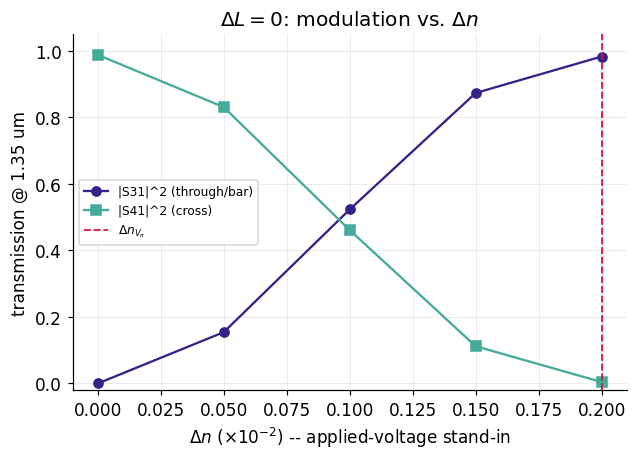

In [15]:
dn_arr = np.array(DELTA_N_SWEEP)
T_through_vs_dn, T_cross_vs_dn = [], []
for dn in DELTA_N_SWEEP:
    res = sweep_results[dn]
    i0 = np.argmin(np.abs(res.wavelengths_um - params["wl0_um"]))
    T_through_vs_dn.append(np.abs(res.S31[i0]) ** 2)
    T_cross_vs_dn.append(np.abs(res.S41[i0]) ** 2)
T_through_vs_dn, T_cross_vs_dn = np.array(T_through_vs_dn), np.array(T_cross_vs_dn)

DN_SCALE = 100   # plot Delta_n in units of 1e-2 -- the raw values (0.0000, 0.0005, 0.0010, ...)
                 # overlap as x-tick labels at this precision; x1e2 gives short, legible ticks
                 # (0.0, 0.5, 1.0, ...) without losing any information.
dn_scaled = dn_arr * DN_SCALE

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(dn_scaled, T_through_vs_dn, "o-", color=style.COLOR_CYCLE[0], label="|S31|^2 (through/bar)")
ax.plot(dn_scaled, T_cross_vs_dn, "s-", color=style.COLOR_CYCLE[2], label="|S41|^2 (cross)")
ax.axvline(params["delta_n_vpi"] * DN_SCALE, color=style.COLOR_ANNOTATION, lw=1.2, ls="--",
           label=r"$\Delta n_{V_\pi}$")
ax.set_xlabel(r"$\Delta n$ ($\times 10^{-2}$) -- applied-voltage stand-in")
ax.set_ylabel(f"transmission @ {params['wl0_um']} um"); ax.set_ylim(-0.02, 1.05)
ax.set_title(r"$\Delta L=0$: modulation vs. $\Delta n$")
ax.legend(fontsize=8)
plt.show()


## 10. Confirming the $V_\pi$ design point

An honest check against the $\pi$ target, mirroring
`PIC_components/MZM/03_mzm_design_v4.ipynb`'s own Section 7a: invert
$T_\mathrm{through}=\sin^2(\Delta\phi/2)$ for the branch nearer $\pi$, then
back out the ACTUAL confinement factor -- no forcing agreement with
`gamma_core_prior`, which was only ever a sizing estimate.

In [14]:
def implied_dphi_from_T_through(T_through, target=np.pi):
    theta = np.arcsin(np.clip(np.sqrt(T_through), 0.0, 1.0))
    candidates = (2 * theta, 2 * np.pi - 2 * theta)
    return min(candidates, key=lambda d: abs(d - target))

T_through_vpi = T_through_vs_dn[-1]
DPHI_MEEP_VPI = implied_dphi_from_T_through(T_through_vpi)
GAMMA_CORE_MEASURED = DPHI_MEEP_VPI / ((2 * np.pi / params["wl0_um"]) * params["delta_n_vpi"] * PLATEAU_LENGTH_UM)

print(f"Meep-implied |dphi| at Delta_n_Vpi = {DPHI_MEEP_VPI:.3f} rad = {DPHI_MEEP_VPI/np.pi:.3f} pi "
      f"(target: 1.000 pi)")
print(f"Measured confinement factor Gamma_core = {GAMMA_CORE_MEASURED:.3f} "
      f"(prior used for sizing: {params['gamma_core_prior']})")
print(f"T_through(off)={T_through_vs_dn[0]:.4f}, T_through(Vpi)={T_through_vs_dn[-1]:.4f}  "
      f"-> modulation {'CONFIRMED' if (T_through_vs_dn[-1]-T_through_vs_dn[0]) > 0.3 else 'NOT clearly seen'}")


Meep-implied |dphi| at Delta_n_Vpi = 2.882 rad = 0.917 pi (target: 1.000 pi)
Measured confinement factor Gamma_core = 0.936 (prior used for sizing: 1.02)
T_through(off)=0.0000, T_through(Vpi)=0.9833  -> modulation CONFIRMED


## 11. Path-length bias check -- does $S_{31}/S_{41}$ still switch at $\Delta L=10\ \mathrm{\mu m}$?

Combining this device's push-pull $\Delta n$ with `mzi.py`'s own geometric
path-length-difference technique (`delta_L_um`): a fixed static phase bias is
added to one arm via a raised-cosine bump (reused directly from `mzi.py`,
not re-implemented -- see `meep_sim/mzm.py`'s module docstring for why an
axis-aligned-Block reimplementation of this bend was tried and rejected
elsewhere). Running at $\Delta n=0$ and $\Delta n=\Delta n_{V_\pi}$ shows
whether the same push-pull drive still flips the device between bar and
cross once that static bias is present.

> **STOP -- this cell runs 2 more full FDTD simulations, on a device whose
> delay-arm bump also widens the transverse cell size (see
> `mzm._compute_domain`) -- individually more expensive than Section 9's own
> runs.**

Unlike Section 6's $\Delta L=0$ case, a nonzero $\Delta L$ adds a fixed geometric phase that depends on wavelength, so the device's response is no longer flat/symmetric across the band -- Section 11 below therefore plots the full spectrum (power and phase) for both $\Delta n$ states, the same 2x2 layout as Section 6, rather than reading out a single wavelength. At $\Delta n=0$ this should reduce to `07_mzi.ipynb`'s own passive-MZI result (same $\Delta L$ mechanism, no active perturbation); switching to $\Delta n=V_\pi$ should swap which of $S_{31}$/$S_{41}$ dominates. Both spectra below use the same  coarse sampling as Section 9 (reused artifacts, not re-simulated at finer resolution), so the fringes appear as straight-line segments between sample points rather than smooth curves -- the FSR-like periodicity and the bar/cross swap are still clearly visible at this sampling density.

In [9]:
DELTA_N_SWEEP_DL = [0.0, params["delta_n_vpi"]]
DELTA_L_UM = 10.0
DL_N_FREQ = SWEEP_N_FREQ * 3   # ~3x Section 9's sweep resolution -- delta_L_um>0 introduces a
                                # real wavelength dependence (a static geometric phase bias, on
                                # top of the push-pull Delta_n), so resolving its fringe pattern
                                # needs more than Section 9's flat-response-appropriate 11 points.
params_dl = {**params, "delta_L_um": DELTA_L_UM, "n_freq": DL_N_FREQ}

dl_results = {}
dl_rows = []
for dn in DELTA_N_SWEEP_DL:
    res = mzm.simulate(params_dl, delta_n_lower=-dn / 2, delta_n_upper=dn / 2,
                        capture_dft=np.isclose(dn, params["delta_n_vpi"]))
    dl_results[dn] = res
    i0 = np.argmin(np.abs(res.wavelengths_um - params["wl0_um"]))
    t31, t41, t11 = np.abs(res.S31[i0]) ** 2, np.abs(res.S41[i0]) ** 2, np.abs(res.S11[i0]) ** 2
    print(f"  delta_L={DELTA_L_UM}um, delta_n={dn:.4f}  ->  |S31|^2={t31:.4f}  |S41|^2={t41:.4f}  "
          f"|S11|^2={t11:.4f}  sum={t31+t41+t11:.4f}")

    tag = f"dn{dn:.4f}".replace(".", "p")
    artifact_stem = f"../data/sparams/mzm/delta_L/mzm_dL{DELTA_L_UM:.0f}_{tag}"
    mzm.save_artifact(artifact_stem, res, {
        "component": "mzm", "delta_L_um": DELTA_L_UM, "delta_n": dn,
        "meep_resolution": params_dl["resolution"], "meep_version": res.sim_params["meep_version"],
        "creation_date": res.sim_params["creation_date"],
    })
    dl_rows.append({"delta_L_um": DELTA_L_UM, "delta_n": dn, "T_through": t31, "T_cross": t41,
                     "artifact_path": artifact_stem})

sweep_mod.save_manifest(dl_rows, "../data/sparams/mzm/delta_L/manifest.csv")


  delta_L=10.0um, delta_n=0.0000  ->  |S31|^2=0.1308  |S41|^2=0.8303  |S11|^2=0.0001  sum=0.9612
  delta_L=10.0um, delta_n=0.0020  ->  |S31|^2=0.5138  |S41|^2=0.4232  |S11|^2=0.0000  sum=0.9370


delta_L=10.0um: at Delta_n=0 the device favors cross (S41) (S31=0.131, S41=0.830)
delta_L=10.0um: at Delta_n=Vpi the device favors bar (S31) (S31=0.514, S41=0.423)
-> bar/cross swap with the static bias present: YES


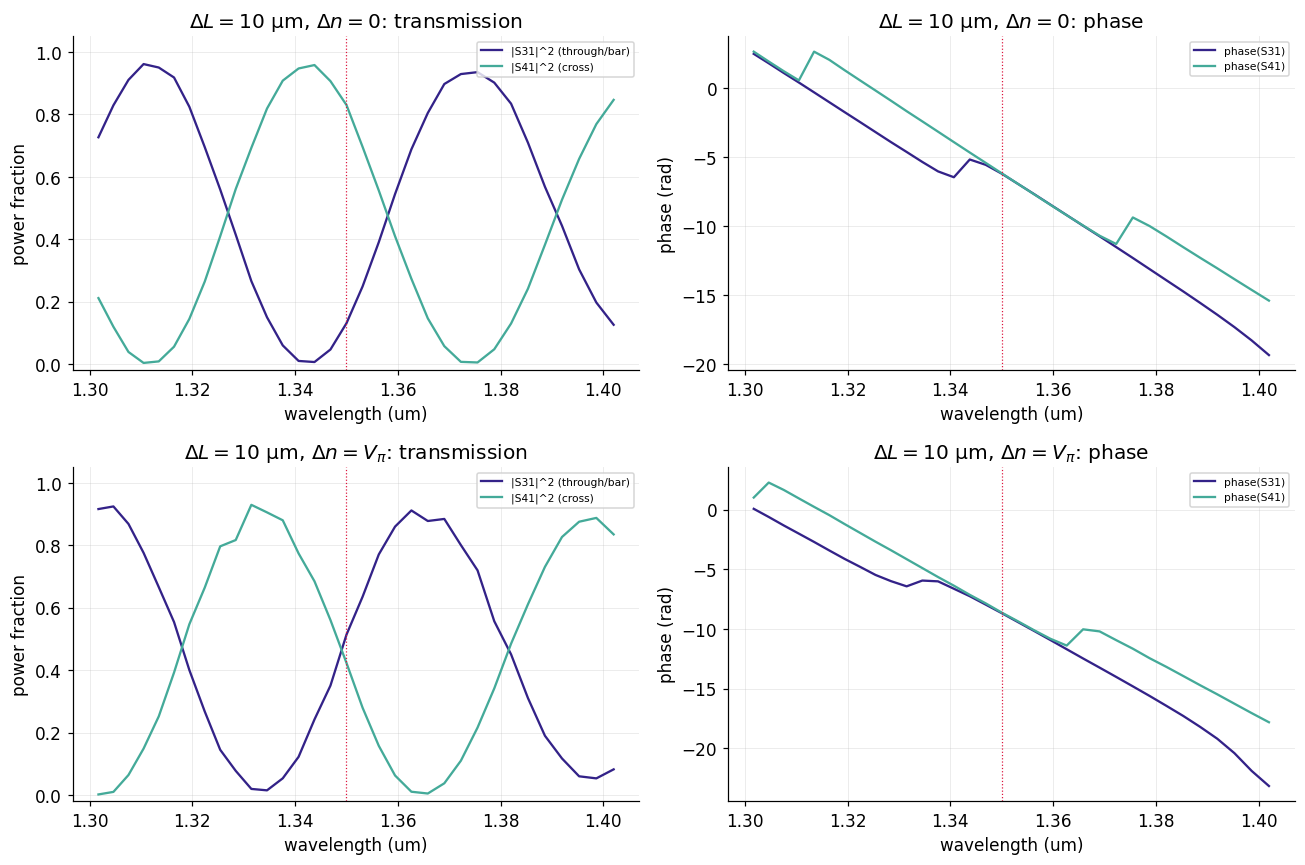

In [15]:
# Re-load from disk (cell 32's own saved artifacts) rather than relying on the in-memory
# dl_results dict, so this cell can be re-run standalone without re-running cell 32's FDTD.
DELTA_L_UM = 10.0   # matches cell 32's own setting
dl_off_artifact = mzm.load_artifact(f"../data/sparams/mzm/delta_L/mzm_dL{DELTA_L_UM:.0f}_dn0p0000")
dl_on_artifact = mzm.load_artifact(f"../data/sparams/mzm/delta_L/mzm_dL{DELTA_L_UM:.0f}_dn0p0020")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
(ax_mag_off, ax_phase_off), (ax_mag_on, ax_phase_on) = axes

for ax_mag, ax_phase, art, label in [
    (ax_mag_off, ax_phase_off, dl_off_artifact, r"$\Delta n=0$"),
    (ax_mag_on, ax_phase_on, dl_on_artifact, r"$\Delta n=V_\pi$"),
]:
    wl = art.wavelengths_um
    order = np.argsort(wl)
    wl_s, S31_s, S41_s = wl[order], art.S31[order], art.S41[order]

    ax_mag.plot(wl_s, np.abs(S31_s) ** 2, color=style.COLOR_CYCLE[0], label="|S31|^2 (through/bar)")
    ax_mag.plot(wl_s, np.abs(S41_s) ** 2, color=style.COLOR_CYCLE[2], label="|S41|^2 (cross)")
    ax_mag.axvline(params["wl0_um"], color=style.COLOR_ANNOTATION, lw=0.8, ls=":")
    ax_mag.set_xlabel("wavelength (um)"); ax_mag.set_ylabel("power fraction"); ax_mag.set_ylim(-0.02, 1.05)
    ax_mag.set_title(rf"$\Delta L={DELTA_L_UM:.0f}\ \mathrm{{\mu m}}$, {label}: transmission")
    ax_mag.legend(fontsize=7)

    ax_phase.plot(wl_s, np.unwrap(np.angle(S31_s)), color=style.COLOR_CYCLE[0], label="phase(S31)")
    ax_phase.plot(wl_s, np.unwrap(np.angle(S41_s)), color=style.COLOR_CYCLE[2], label="phase(S41)")
    ax_phase.axvline(params["wl0_um"], color=style.COLOR_ANNOTATION, lw=0.8, ls=":")
    ax_phase.set_xlabel("wavelength (um)"); ax_phase.set_ylabel("phase (rad)")
    ax_phase.set_title(rf"$\Delta L={DELTA_L_UM:.0f}\ \mathrm{{\mu m}}$, {label}: phase")
    ax_phase.legend(fontsize=7)

fig.tight_layout()
plt.show()

i0_off = np.argmin(np.abs(dl_off_artifact.wavelengths_um - params["wl0_um"]))
i0_on = np.argmin(np.abs(dl_on_artifact.wavelengths_um - params["wl0_um"]))
S31_off, S41_off = np.abs(dl_off_artifact.S31[i0_off]) ** 2, np.abs(dl_off_artifact.S41[i0_off]) ** 2
S31_on, S41_on = np.abs(dl_on_artifact.S31[i0_on]) ** 2, np.abs(dl_on_artifact.S41[i0_on]) ** 2

dominant_off = "bar (S31)" if S31_off > S41_off else "cross (S41)"
dominant_on = "bar (S31)" if S31_on > S41_on else "cross (S41)"
print(f"delta_L={DELTA_L_UM}um: at Delta_n=0 the device favors {dominant_off} (S31={S31_off:.3f}, S41={S41_off:.3f})")
print(f"delta_L={DELTA_L_UM}um: at Delta_n=Vpi the device favors {dominant_on} (S31={S31_on:.3f}, S41={S41_on:.3f})")
print(f"-> bar/cross swap with the static bias present: {'YES' if dominant_off != dominant_on else 'NO'}")


## 12. Save design point

In [16]:
design_point_path = "../data/design_points/mzm.yaml"
design_points.save_design_point(design_point_path, {
    "component": "mzm",
    "parameters": {k: params[k] for k in [
        "coupling_length_um", "gap_um", "wg_width_um", "wg_height_um", "core_index", "clad_index",
        "sbend_len_um", "wide_sep_um", "delta_n_vpi", "sigma_um", "margin_sigma",
    ]},
    "arm_length_um": ARM_LENGTH_UM, "plateau_length_um": PLATEAU_LENGTH_UM,
    "gamma_core_prior": params["gamma_core_prior"], "gamma_core_measured": float(GAMMA_CORE_MEASURED),
    "dphi_meep_at_vpi_pi": float(DPHI_MEEP_VPI / np.pi),
    "source_artifact": "data/sparams/mzm/baseline/mzm_baseline",
    "provenance": {
        "method": "vpi_defined_arm_length_derivation",
        "date": result.sim_params["creation_date"],
        "meep_version": result.sim_params["meep_version"],
    },
    "validation": validation,
    "rationale": (
        "Delta_n_vpi=0.002 is an explicitly chosen design target (push-pull, n_upper/n_lower = "
        "core_index +/- Delta_n/2), not a value found by sweep-and-select. The arm length is "
        "derived from this target via an idealized formula corrected by gamma_core_prior "
        "(reused from PIC_components/MZM/03_mzm_design_v4.ipynb's own embedded-device "
        "calibration at a different Delta_n regime), then Meep-validated directly (Section 10): "
        f"the achieved phase swing is {DPHI_MEEP_VPI/np.pi:.3f} pi against a 1.000 pi target. "
        "Edit this rationale directly if a different Delta_n_vpi or gamma_core_prior is preferred."
    ),
})
print("saved:", design_point_path)


saved: ../data/design_points/mzm.yaml


## 13. MZM SAX model

Not exercised in this notebook -- `models/mzm.py` must work in a process
where `meep` was never imported, so its own correctness is checked
separately (CLAUDE.md's verification checklist), not here.

In [17]:
with open("../src/pic_toolkit/models/mzm.py") as f:
    print(f.read())


"""SAX-compatible component model for the Mach-Zehnder Modulator.

Architectural rule: this file NEVER imports meep, and NEVER launches an FDTD
simulation -- same rule as models/mzi.py, models/coupler.py, etc. It reads
the cached, validated artifact that notebooks/08_mzm.ipynb already produced
at the Vpi push-pull-ON operating point, via the design point that names it.

Unlike models/coupler.py (sqrt(power)-only, zero-phase S-parameters), this
model returns genuine COMPLEX S-parameters directly, since
meep_sim.mzm.simulate_baseline records real phase, not just power -- same
convention models/mzi.py already established.

This model exposes ONE fixed operating point (the cached Vpi-ON baseline);
it does not interpolate across Delta_n the way a real voltage-driven device
would need to. A Delta_n-dependent circuit model is future work -- see
notebooks/08_mzm.ipynb Section 10's Delta_n sweep for the underlying
Meep-measured data this would be built from.
"""

from __future__ import annotati

## 14. Summary

**Files created**
- `notebooks/08_mzm.ipynb` (this notebook)
- `src/pic_toolkit/meep_sim/mzm.py`
- `src/pic_toolkit/models/mzm.py`
- `data/design_points/mzm.yaml`
- `data/sparams/mzm/baseline/mzm_baseline.{npz,json}`
- `data/sparams/mzm/sweep/mzm_*.{npz,json}` + `manifest.csv`
- `data/sparams/mzm/delta_L/mzm_*.{npz,json}` + `manifest.csv`

This closes the "active" counterpart to `07_mzi.ipynb`'s passive MZI:
together, `coupler.py` (splitter/combiner), `mzi.py` (passive interference),
and `mzm.py` (active, voltage-driven interference) now cover both the
building block and both circuit-level uses `circuits/README.md` names.

**Limitations**
1. `gamma_core_prior` is reused from a different $\Delta n$ regime (v4's
   push-pull differential was 10x larger); Section 10 measures the real
   value at this notebook's own operating point and reports it without
   forcing agreement.
2. The $\Delta n$ sweep (Section 9) and $\Delta L$ check (Section 11) use
   single-excitation `simulate()`, not the dual-excitation
   `simulate_baseline()` -- no reciprocity check at those points, only at
   the one canonical baseline.
3. As in every earlier notebook in this series, the electrical
   (voltage $\to$ carrier density $\to$ $\Delta n$) mechanism is not modeled.
4. `models/mzm.py` exposes one fixed operating point (the cached $V_\pi$-ON
   baseline) rather than a $\Delta n$-dependent circuit model.